In [1]:
import os
import random
import json
import shutil
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter
from tqdm import tqdm
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [2]:
INPUT_DIR  = "/kaggle/input/datasets/aryansinghal10/alzheimers-multiclass-dataset-equal-and-augmented/combined_images"
OUTPUT_DIR = "/kaggle/working/preprocessed"
CKPT_PATH  = "/kaggle/working/best_model.pt"
META_PATH  = "/kaggle/working/meta.json"

IMAGE_SIZE   = 224
USE_RATIO    = 1.0   
TRAIN_RATIO  = 0.80
VAL_RATIO    = 0.10

BATCH_SIZE   = 64
NUM_EPOCHS   = 40
LR_HEAD      = 1e-3
LR_BACKBONE  = 1e-4
WEIGHT_DECAY = 1e-4
PATIENCE     = 7

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

CLASS_NAMES = sorted(os.listdir(INPUT_DIR))
NUM_CLASSES = len(CLASS_NAMES)
print(f'Classes ({NUM_CLASSES}): {CLASS_NAMES}')

Classes (4): ['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']


In [3]:
all_paths  = []
all_labels = []

for idx, cls in enumerate(CLASS_NAMES):
    cls_dir = os.path.join(INPUT_DIR, cls)
    files   = [f for f in os.listdir(cls_dir)
               if os.path.isfile(os.path.join(cls_dir, f))]
    random.shuffle(files)
    n = int(len(files) * USE_RATIO)
    for fname in files[:n]:
        all_paths.append(os.path.join(cls_dir, fname))
        all_labels.append(idx)

print(f"Total images (USE_RATIO={USE_RATIO}): {len(all_paths)}")
for idx, cls in enumerate(CLASS_NAMES):
    print(f"  {cls}: {all_labels.count(idx)}")

Total images (USE_RATIO=1.0): 44000
  MildDemented: 10000
  ModerateDemented: 10000
  NonDemented: 12800
  VeryMildDemented: 11200


In [4]:
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    all_paths, all_labels,
    test_size=1 - TRAIN_RATIO,
    stratify=all_labels,
    random_state=SEED,
)
val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels,
    test_size=0.5,
    stratify=temp_labels,
    random_state=SEED,
)

print(f"Train: {len(train_paths)} | Val: {len(val_paths)} | Test: {len(test_paths)}")
for name, lbls in [("train", train_labels), ("val", val_labels), ("test", test_labels)]:
    c = Counter(lbls)
    print(f"  {name}:", {CLASS_NAMES[k]: v for k, v in sorted(c.items())})

Train: 35200 | Val: 4400 | Test: 4400
  train: {'MildDemented': 8000, 'ModerateDemented': 8000, 'NonDemented': 10240, 'VeryMildDemented': 8960}
  val: {'MildDemented': 1000, 'ModerateDemented': 1000, 'NonDemented': 1280, 'VeryMildDemented': 1120}
  test: {'MildDemented': 1000, 'ModerateDemented': 1000, 'NonDemented': 1280, 'VeryMildDemented': 1120}


In [5]:
# Clean any leftover files from previous runs
if os.path.exists(OUTPUT_DIR):
    shutil.rmtree(OUTPUT_DIR)
os.makedirs(OUTPUT_DIR, exist_ok=True)


def save_tensors(paths, labels, split_name):
    """
    Resize image to 224x224, convert to grayscale, repeat to 3ch,
    save as uint8 tensor. Normalization happens later in __getitem__.
    """
    split_dir = os.path.join(OUTPUT_DIR, split_name)

    for path, label in tqdm(zip(paths, labels), total=len(paths),
                            desc=f"Saving {split_name}"):
        cls_name = CLASS_NAMES[label]
        out_dir  = os.path.join(split_dir, cls_name)
        os.makedirs(out_dir, exist_ok=True)

        out_path = os.path.join(out_dir,
                    os.path.splitext(os.path.basename(path))[0] + ".pt")

        img    = Image.open(path).convert("L")          # grayscale
        img    = img.resize((IMAGE_SIZE, IMAGE_SIZE))   # 224x224
        tensor = transforms.ToTensor()(img)             # [1, 224, 224] float32 0-1
        tensor = (tensor * 255).byte()                  # → uint8, saves 4x space
        tensor = tensor.repeat(3, 1, 1)                 # [3, 224, 224] uint8
        torch.save(tensor, out_path)


save_tensors(train_paths, train_labels, "train")
save_tensors(val_paths,   val_labels,   "val")
save_tensors(test_paths,  test_labels,  "test")

print("\nAll tensors saved.")

Saving test: 100%|██████████| 4400/4400 [00:41<00:00, 106.53it/s]


All tensors saved.


In [6]:
# Augmentation applied on-the-fly to training tensors (already uint8 3ch)
train_augment = transforms.Compose([
    transforms.RandomRotation(degrees=10),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.RandomAdjustSharpness(sharpness_factor=1.5, p=0.3),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 0.5)),
])

# Normalization: uint8 → float32 → ImageNet normalize
normalize = transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)


class AlzheimerDataset(Dataset):
    def __init__(self, split_dir: str, class_names: list, augment: bool = False):
        self.samples  = []
        self.augment  = augment

        for idx, cls in enumerate(class_names):
            cls_dir = os.path.join(split_dir, cls)
            if not os.path.isdir(cls_dir):
                continue
            for fname in os.listdir(cls_dir):
                if fname.endswith(".pt"):
                    self.samples.append((os.path.join(cls_dir, fname), idx))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        tensor = torch.load(path, weights_only=True)          # uint8 [3,224,224]
        tensor = tensor.float() / 255.0                       # → float32 [0,1]
        if self.augment:
            tensor = train_augment(tensor)
        tensor = normalize(tensor)                            # ImageNet normalize
        return tensor, label

    def get_labels(self):
        return [s[1] for s in self.samples]


train_ds = AlzheimerDataset(os.path.join(OUTPUT_DIR, "train"), CLASS_NAMES, augment=True)
val_ds   = AlzheimerDataset(os.path.join(OUTPUT_DIR, "val"),   CLASS_NAMES, augment=False)
test_ds  = AlzheimerDataset(os.path.join(OUTPUT_DIR, "test"),  CLASS_NAMES, augment=False)

print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")

Train: 35200 | Val: 4400 | Test: 4400


In [7]:
# WeightedRandomSampler for class imbalance
train_labels_list = train_ds.get_labels()
class_counts      = Counter(train_labels_list)
class_weights     = {cls: 1.0 / cnt for cls, cnt in class_counts.items()}
sample_weights    = [class_weights[lbl] for lbl in train_labels_list]

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True,
)

# num_workers=4 + persistent_workers: parallel disk reads while GPU computes
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,
                          num_workers=4, pin_memory=True, persistent_workers=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=4, pin_memory=True, persistent_workers=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=4, pin_memory=True, persistent_workers=True)

print("DataLoaders ready.")
print("Class weights:", {CLASS_NAMES[k]: round(v, 5) for k, v in sorted(class_weights.items())})

DataLoaders ready.
Class weights: {'MildDemented': 0.00013, 'ModerateDemented': 0.00013, 'NonDemented': 0.0001, 'VeryMildDemented': 0.00011}


In [8]:
# =========================
# ResNet50 + Softmax Paper-Style Model
# =========================

def build_model(num_classes: int) -> nn.Module:
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)

    in_features = model.fc.in_features  # 2048

    model.fc = nn.Sequential(
        nn.BatchNorm1d(in_features),
        nn.Dropout(p=0.5),
        nn.Linear(in_features, num_classes)
    )

    return model


model = build_model(NUM_CLASSES).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.SGD(
    model.parameters(),
    lr=0.0004,
    momentum=0.9,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=NUM_EPOCHS,
    eta_min=1e-6
)

scaler = torch.amp.GradScaler()

total = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total params: {total:,}")
print(f"Trainable params: {trainable:,}")
print(model.fc)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 158MB/s] 


Total params: 23,520,324
Trainable params: 23,520,324
Sequential(
  (0): BatchNorm1d(2048, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (1): Dropout(p=0.5, inplace=False)
  (2): Linear(in_features=2048, out_features=4, bias=True)
)


In [9]:
def run_epoch(loader, model, criterion, optimizer=None, scaler=None, desc=""):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss, correct, total = 0.0, 0, 0

    with (torch.enable_grad() if is_train else torch.no_grad()):
        for images, labels in tqdm(loader, desc=desc, leave=False):
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            with torch.amp.autocast(device_type='cuda'):
                outputs = model(images)
                loss    = criterion(outputs, labels)

            if is_train:
                optimizer.zero_grad()
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()

            correct    += (outputs.argmax(1) == labels).sum().item()
            total_loss += loss.item() * labels.size(0)
            total      += labels.size(0)

    return total_loss / total, correct / total


history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc, patience_ctr = 0.0, 0

for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(train_loader, model, criterion, optimizer, scaler,
                                desc=f"Epoch {epoch}/{NUM_EPOCHS} [train]")
    vl_loss, vl_acc = run_epoch(val_loader, model, criterion,
                                desc=f"Epoch {epoch}/{NUM_EPOCHS} [val]")
    scheduler.step()

    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)
    history['val_loss'].append(vl_loss)
    history['val_acc'].append(vl_acc)

    print(f"Epoch {epoch:02d} | "
          f"train loss={tr_loss:.4f} acc={tr_acc*100:.2f}% | "
          f"val loss={vl_loss:.4f} acc={vl_acc*100:.2f}%")

    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        torch.save(model.state_dict(), CKPT_PATH)
        patience_ctr = 0
        print(f"  Best val_acc={best_val_acc*100:.2f}% — checkpoint saved.")
    else:
        patience_ctr += 1
        if patience_ctr >= PATIENCE:
            print(f"  Early stopping at epoch {epoch}.")
            break

print(f"\nDone. Best val accuracy: {best_val_acc*100:.2f}%")

Epoch 01 | train loss=0.9599 acc=57.99% | val loss=0.6500 acc=72.09%
  Best val_acc=72.09% — checkpoint saved.


Epoch 02 | train loss=0.5988 acc=73.91% | val loss=0.4531 acc=80.95%
  Best val_acc=80.95% — checkpoint saved.


Epoch 03 | train loss=0.4443 acc=81.09% | val loss=0.3269 acc=86.55%
  Best val_acc=86.55% — checkpoint saved.


Epoch 04 | train loss=0.3297 acc=86.33% | val loss=0.2288 acc=90.64%
  Best val_acc=90.64% — checkpoint saved.


Epoch 05 | train loss=0.2387 acc=90.51% | val loss=0.1691 acc=93.68%
  Best val_acc=93.68% — checkpoint saved.


...

Epoch 33 | train loss=0.0090 acc=99.69% | val loss=0.0113 acc=99.73%


Epoch 34 | train loss=0.0088 acc=99.72% | val loss=0.0108 acc=99.75%


Epoch 35 | train loss=0.0098 acc=99.65% | val loss=0.0112 acc=99.75%


Epoch 36 | train loss=0.0099 acc=99.68% | val loss=0.0103 acc=99.77%


Epoch 37 | train loss=0.0084 acc=99.74% | val loss=0.0106 acc=99.75%
  Early stopping at epoch 37.

Done. Best val accuracy: 99.77%


In [10]:
# =========================
# ResNet50 + Softmax Evaluation
# =========================

model.load_state_dict(torch.load(CKPT_PATH, map_location=device))
model.eval()

all_preds = []
all_true = []
all_probs = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Testing ResNet50 + Softmax"):
        images = images.to(device)
        labels = labels.to(device)

        logits = model(images)

        # Softmax probabilities
        probs = torch.softmax(logits, dim=1)

        preds = probs.argmax(dim=1)

        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_true.extend(labels.cpu().numpy())

all_probs = np.array(all_probs)
all_preds = np.array(all_preds)
all_true = np.array(all_true)

test_acc = np.mean(all_preds == all_true)

print(f"ResNet50 + Softmax Test Accuracy: {test_acc*100:.2f}%\n")
print(classification_report(all_true, all_preds, target_names=CLASS_NAMES))

Testing ResNet50 + Softmax: 100%|██████████| 69/69 [00:18<00:00,  3.83it/s]

ResNet50 + Softmax Test Accuracy: 99.70%

                  precision    recall  f1-score   support

    MildDemented       1.00      1.00      1.00      1000
ModerateDemented       1.00      1.00      1.00      1000
     NonDemented       1.00      1.00      1.00      1280
VeryMildDemented       0.99      1.00      1.00      1120

        accuracy                           1.00      4400
       macro avg       1.00      1.00      1.00      4400
    weighted avg       1.00      1.00      1.00      4400



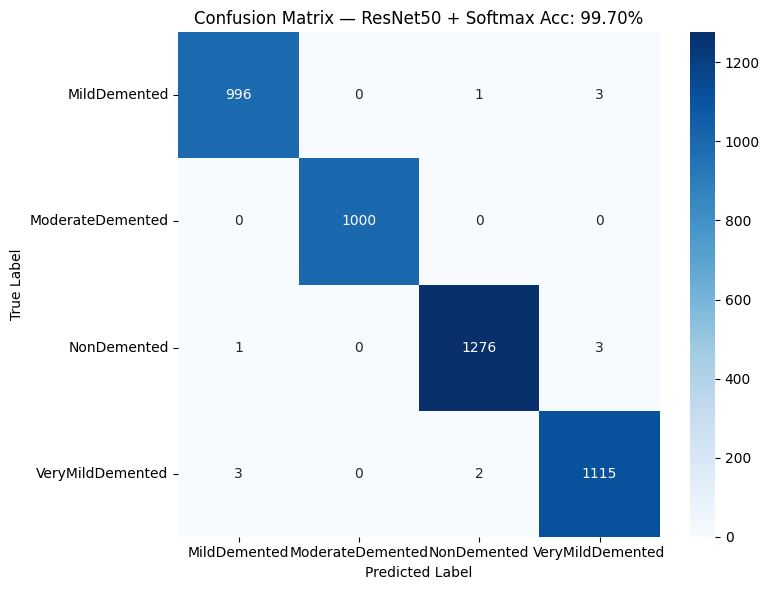

In [11]:
# =========================
# Confusion Matrix — ResNet50 + Softmax
# =========================

cm = confusion_matrix(all_true, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title(f"Confusion Matrix — ResNet50 + Softmax Acc: {test_acc*100:.2f}%")
plt.tight_layout()
plt.savefig("/kaggle/working/resnet50_softmax_confusion_matrix.png", dpi=150)
plt.show()

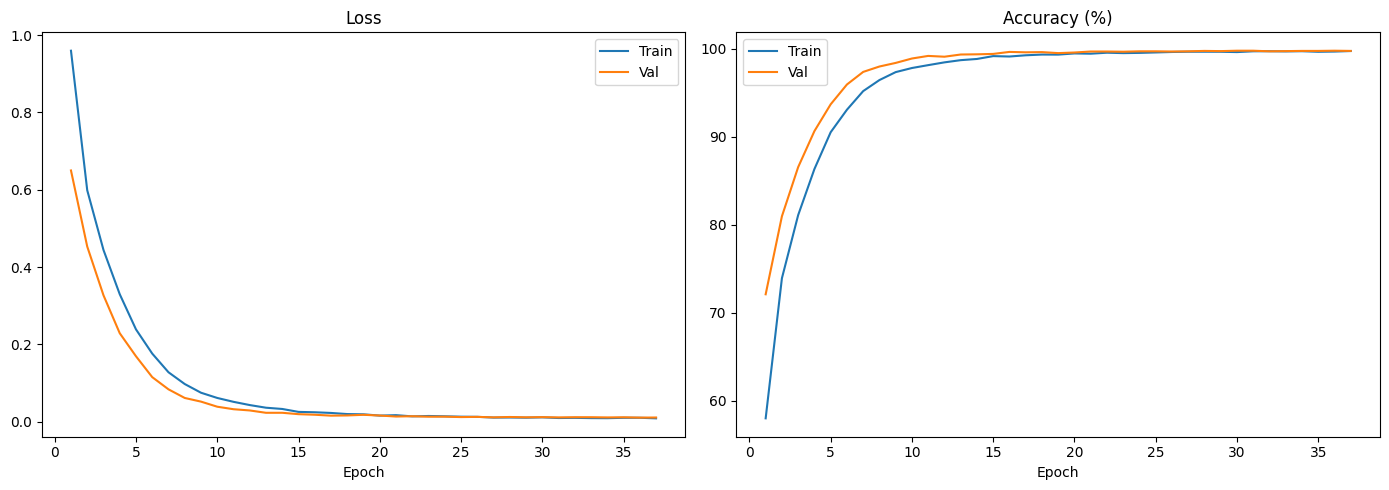

In [12]:
epochs_range = range(1, len(history['train_loss']) + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(epochs_range, history['train_loss'], label='Train')
axes[0].plot(epochs_range, history['val_loss'],   label='Val')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()
axes[1].plot(epochs_range, [a*100 for a in history['train_acc']], label='Train')
axes[1].plot(epochs_range, [a*100 for a in history['val_acc']],   label='Val')
axes[1].set_title('Accuracy (%)'); axes[1].set_xlabel('Epoch'); axes[1].legend()
plt.tight_layout()
plt.savefig('/kaggle/working/training_curves.png', dpi=150)
plt.show()

In [13]:
import torch
import numpy as np
import matplotlib.pyplot as plt

model.eval()

class_names = CLASS_NAMES
n_classes = len(class_names)

xai_images = {}
xai_labels = {}

with torch.no_grad():
    for imgs, labels in test_loader:
        for img, lbl in zip(imgs, labels):
            idx = int(lbl.item())
            if idx not in xai_images:
                xai_images[idx] = img.clone()
                xai_labels[idx] = idx
            if len(xai_images) == n_classes:
                break
        if len(xai_images) == n_classes:
            break

print(f"Collected {len(xai_images)} images")
for i in range(n_classes):
    print(i, class_names[i], xai_images[i].shape)

Collected 4 images
0 MildDemented torch.Size([3, 224, 224])
1 ModerateDemented torch.Size([3, 224, 224])
2 NonDemented torch.Size([3, 224, 224])
3 VeryMildDemented torch.Size([3, 224, 224])


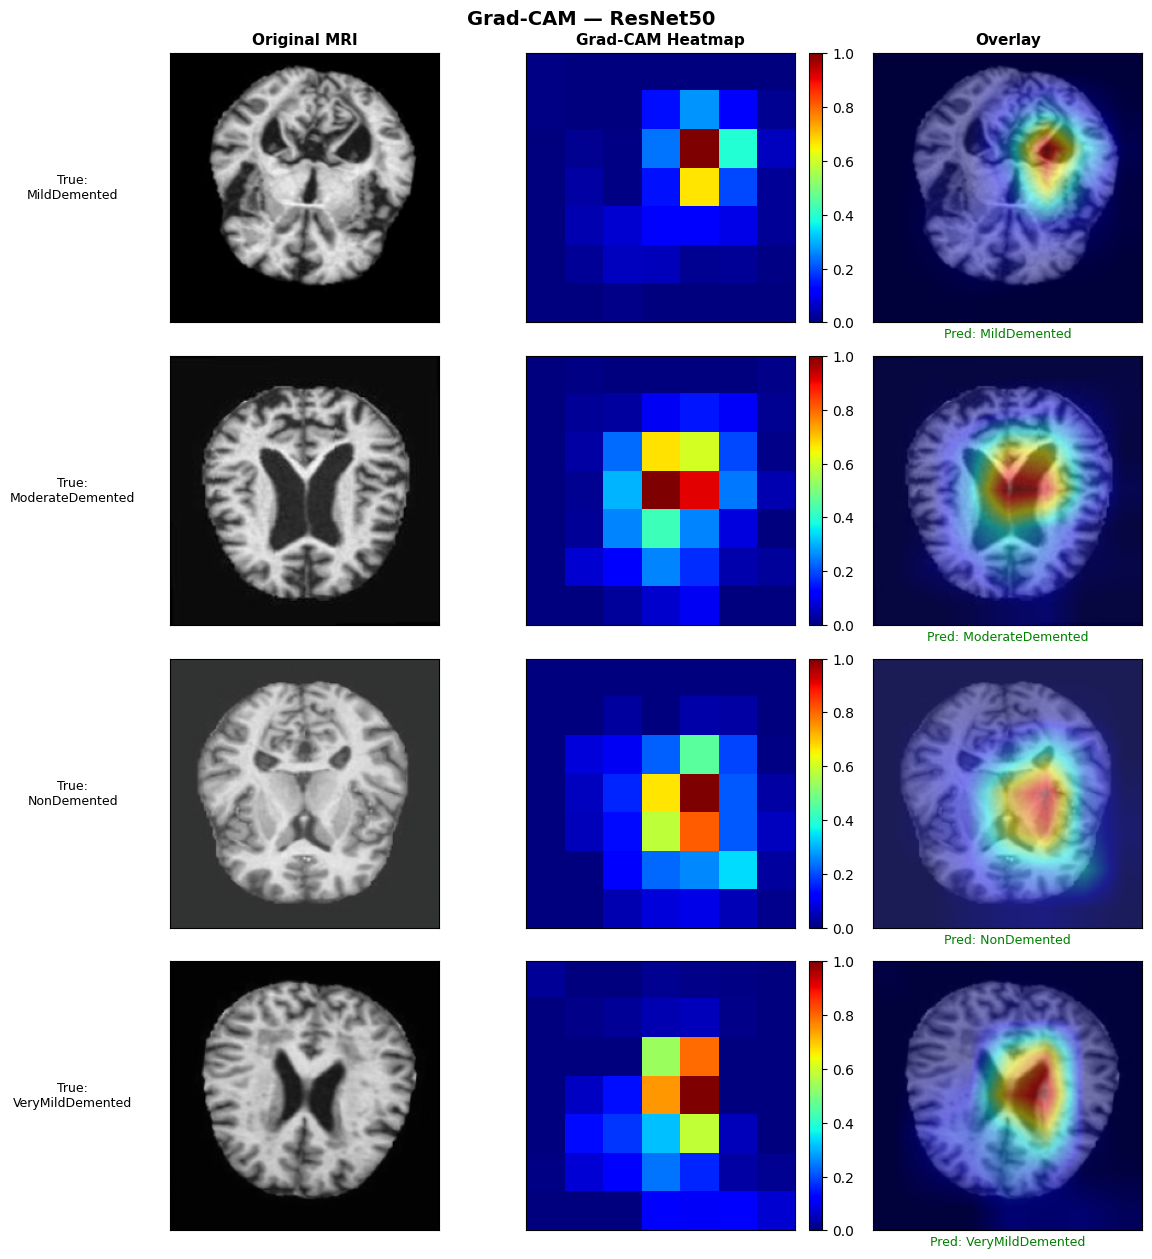

In [14]:
# =========================
# GRAD-CAM for ResNet50
# =========================

import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import cv2

target_layer = model.layer4[-1]

activations = None
gradients = None

def forward_hook(module, input, output):
    global activations
    activations = output

def backward_hook(module, grad_input, grad_output):
    global gradients
    gradients = grad_output[0]

target_layer.register_forward_hook(forward_hook)
target_layer.register_full_backward_hook(backward_hook)

def denormalize(img_tensor):
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    img = img_tensor.cpu() * std + mean
    img = torch.clamp(img, 0, 1)
    return img.permute(1, 2, 0).numpy()

def make_gradcam(img_tensor):
    model.zero_grad()

    inp = img_tensor.unsqueeze(0).to(device)
    output = model(inp)

    pred_idx = output.argmax(dim=1).item()
    score = output[:, pred_idx]

    score.backward()

    grads = gradients[0]
    acts = activations[0]

    weights = grads.mean(dim=(1, 2))
    cam = torch.zeros(acts.shape[1:], device=device)

    for i, w in enumerate(weights):
        cam += w * acts[i]

    cam = F.relu(cam)
    cam = cam.detach().cpu().numpy()

    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
    return cam, pred_idx

def overlay_gradcam(img_np, cam, alpha=0.45):
    h, w = img_np.shape[:2]
    cam_resized = cv2.resize(cam, (w, h))
    heatmap = np.uint8(255 * cam_resized)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

    base = np.uint8(img_np * 255)
    overlay = cv2.addWeighted(base, 1 - alpha, heatmap, alpha, 0)
    return overlay

fig, axes = plt.subplots(n_classes, 3, figsize=(12, n_classes * 3.2))
fig.suptitle("Grad-CAM — ResNet50", fontsize=14, fontweight="bold")

for col, title in enumerate(["Original MRI", "Grad-CAM Heatmap", "Overlay"]):
    axes[0][col].set_title(title, fontsize=11, fontweight="bold")

for row in range(n_classes):
    img_tensor = xai_images[row]
    img_np = denormalize(img_tensor)

    cam, pred_idx = make_gradcam(img_tensor)
    overlay = overlay_gradcam(img_np, cam)

    axes[row][0].imshow(img_np)
    axes[row][0].set_ylabel(f"True:\n{class_names[row]}", fontsize=9, rotation=0, labelpad=70, va="center")

    im = axes[row][1].imshow(cam, cmap="jet")
    plt.colorbar(im, ax=axes[row][1], fraction=0.046, pad=0.04)

    axes[row][2].imshow(overlay)
    axes[row][2].set_xlabel(
        f"Pred: {class_names[pred_idx]}",
        fontsize=9,
        color="green" if pred_idx == row else "red"
    )

    for ax in axes[row]:
        ax.set_xticks([])
        ax.set_yticks([])

plt.tight_layout()
plt.savefig("/kaggle/working/resnet_gradcam.png", dpi=150, bbox_inches="tight")
plt.show()

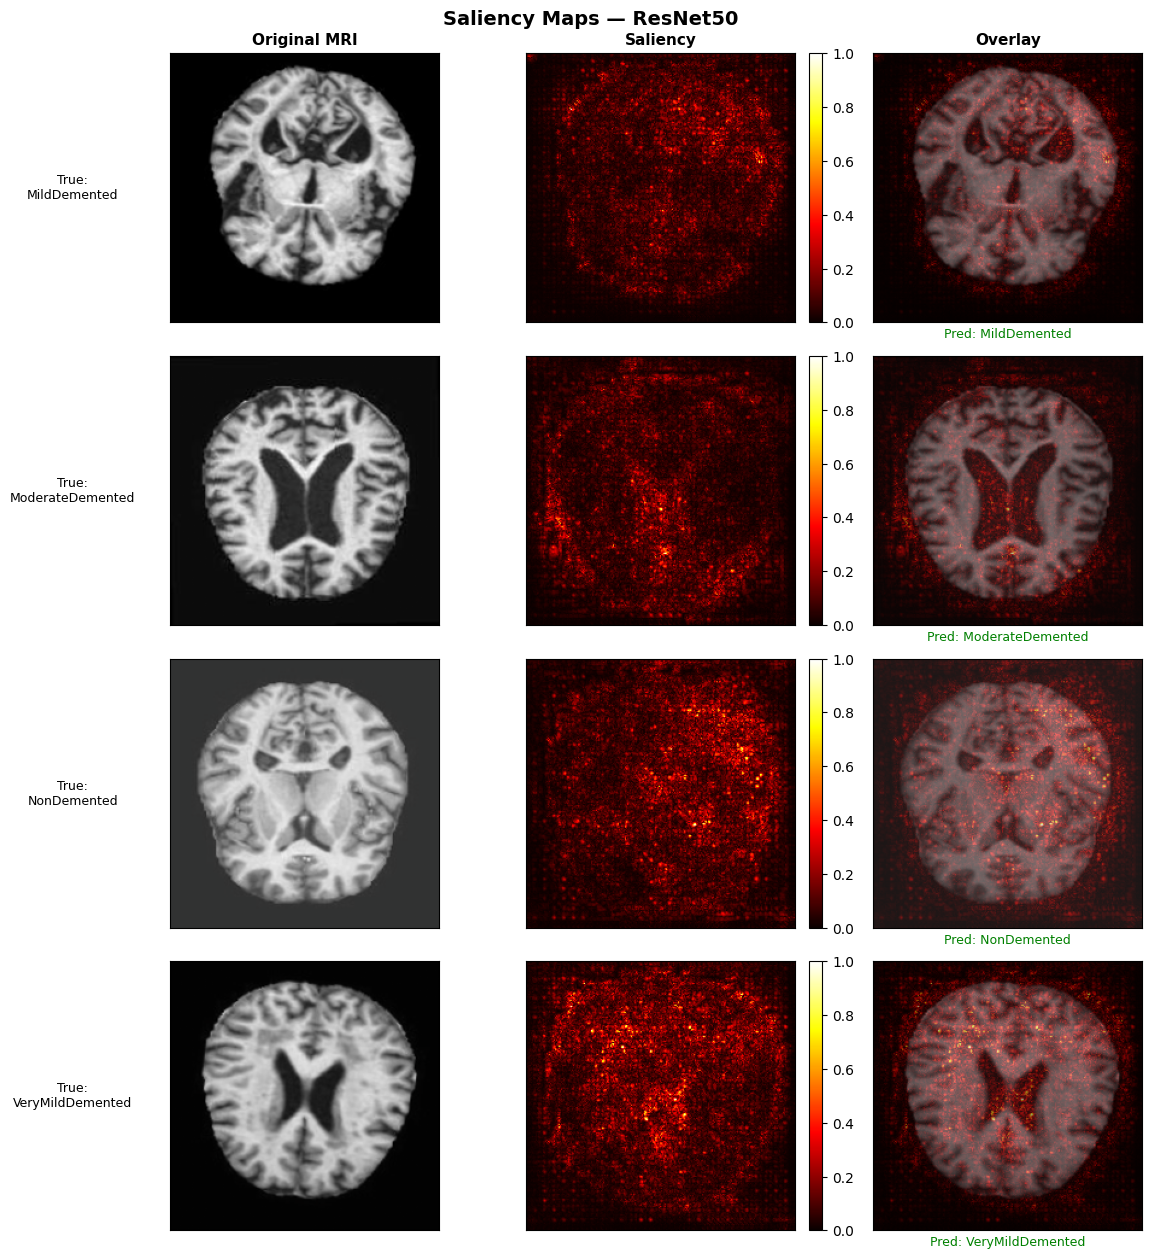

In [15]:
# =========================
# SALIENCY MAP for ResNet50
# =========================

fig, axes = plt.subplots(n_classes, 3, figsize=(12, n_classes * 3.2))
fig.suptitle("Saliency Maps — ResNet50", fontsize=14, fontweight="bold")

for col, title in enumerate(["Original MRI", "Saliency", "Overlay"]):
    axes[0][col].set_title(title, fontsize=11, fontweight="bold")

for row in range(n_classes):
    img_tensor = xai_images[row].clone().unsqueeze(0).to(device)
    img_tensor.requires_grad = True

    output = model(img_tensor)
    pred_idx = output.argmax(dim=1).item()
    score = output[:, pred_idx]

    model.zero_grad()
    score.backward()

    saliency = img_tensor.grad.abs().max(dim=1)[0][0].detach().cpu().numpy()
    saliency = (saliency - saliency.min()) / (saliency.max() - saliency.min() + 1e-8)

    img_np = denormalize(xai_images[row])

    axes[row][0].imshow(img_np)
    axes[row][0].set_ylabel(f"True:\n{class_names[row]}", fontsize=9, rotation=0, labelpad=70, va="center")

    im = axes[row][1].imshow(saliency, cmap="hot")
    plt.colorbar(im, ax=axes[row][1], fraction=0.046, pad=0.04)

    axes[row][2].imshow(img_np)
    axes[row][2].imshow(saliency, cmap="hot", alpha=0.55)
    axes[row][2].set_xlabel(
        f"Pred: {class_names[pred_idx]}",
        fontsize=9,
        color="green" if pred_idx == row else "red"
    )

    for ax in axes[row]:
        ax.set_xticks([])
        ax.set_yticks([])

plt.tight_layout()
plt.savefig("/kaggle/working/resnet_saliency.png", dpi=150, bbox_inches="tight")
plt.show()

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

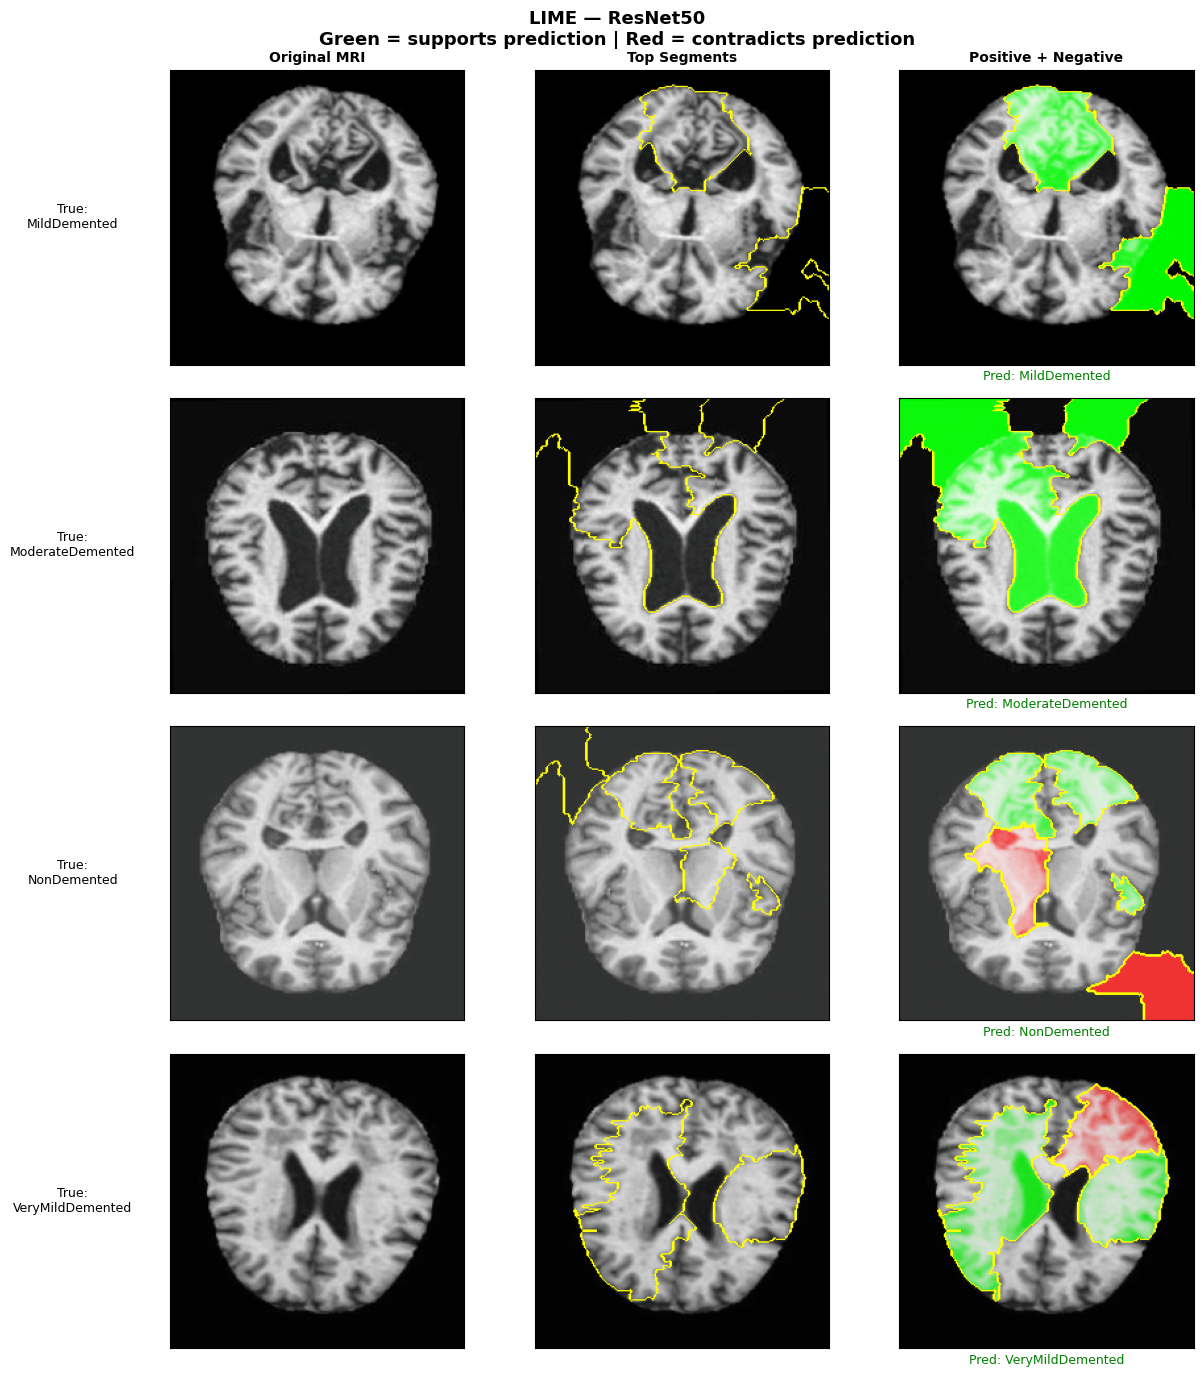

In [16]:
# =========================
# LIME for ResNet50
# =========================

!pip install lime -q

from lime import lime_image
from skimage.segmentation import mark_boundaries

lime_explainer = lime_image.LimeImageExplainer()

def preprocess_lime(images):
    batch = []
    for img in images:
        img = img.astype(np.float32) / 255.0
        img = torch.tensor(img).permute(2, 0, 1)

        normalize_t = transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
        img = normalize_t(img)

        batch.append(img)

    batch = torch.stack(batch).to(device)

    with torch.no_grad():
        outputs = model(batch)
        probs = torch.softmax(outputs, dim=1).cpu().numpy()

    return probs

fig, axes = plt.subplots(n_classes, 3, figsize=(13, n_classes * 3.5))
fig.suptitle(
    "LIME — ResNet50\nGreen = supports prediction | Red = contradicts prediction",
    fontsize=13,
    fontweight="bold"
)

for col, title in enumerate(["Original MRI", "Top Segments", "Positive + Negative"]):
    axes[0][col].set_title(title, fontsize=10, fontweight="bold")

for row in range(n_classes):
    img_np = denormalize(xai_images[row])
    img_uint8 = np.uint8(img_np * 255)

    explanation = lime_explainer.explain_instance(
        img_uint8,
        preprocess_lime,
        top_labels=n_classes,
        hide_color=0,
        num_samples=1000
    )

    pred_idx = explanation.top_labels[0]

    temp1, mask1 = explanation.get_image_and_mask(
        pred_idx,
        positive_only=True,
        num_features=5,
        hide_rest=False
    )

    temp2, mask2 = explanation.get_image_and_mask(
        pred_idx,
        positive_only=False,
        num_features=5,
        hide_rest=False
    )

    axes[row][0].imshow(img_uint8)
    axes[row][0].set_ylabel(f"True:\n{class_names[row]}", fontsize=9, rotation=0, labelpad=70, va="center")

    axes[row][1].imshow(mark_boundaries(temp1 / 255.0, mask1))
    axes[row][2].imshow(mark_boundaries(temp2 / 255.0, mask2))
    axes[row][2].set_xlabel(
        f"Pred: {class_names[pred_idx]}",
        fontsize=9,
        color="green" if pred_idx == row else "red"
    )

    for ax in axes[row]:
        ax.set_xticks([])
        ax.set_yticks([])

plt.tight_layout()
plt.savefig("/kaggle/working/resnet_lime.png", dpi=150, bbox_inches="tight")
plt.show()

In [17]:
# =========================
# SHAP GradientExplainer for ResNet50
# =========================

!pip install shap -q

import shap

model.eval()

background_list = []
count = 0

for imgs, _ in test_loader:
    for img in imgs:
        background_list.append(img)
        count += 1
        if count >= 20:
            break
    if count >= 20:
        break

background = torch.stack(background_list).to(device)
test_array = torch.stack([xai_images[i] for i in range(n_classes)]).to(device)

print("Background:", background.shape)
print("Test array:", test_array.shape)

explainer = shap.GradientExplainer(model, background)
shap_values = explainer.shap_values(test_array)

print("SHAP done")

Background: torch.Size([20, 3, 224, 224])
Test array: torch.Size([4, 3, 224, 224])
SHAP done


Number of SHAP classes: 4
Number of class names: 4


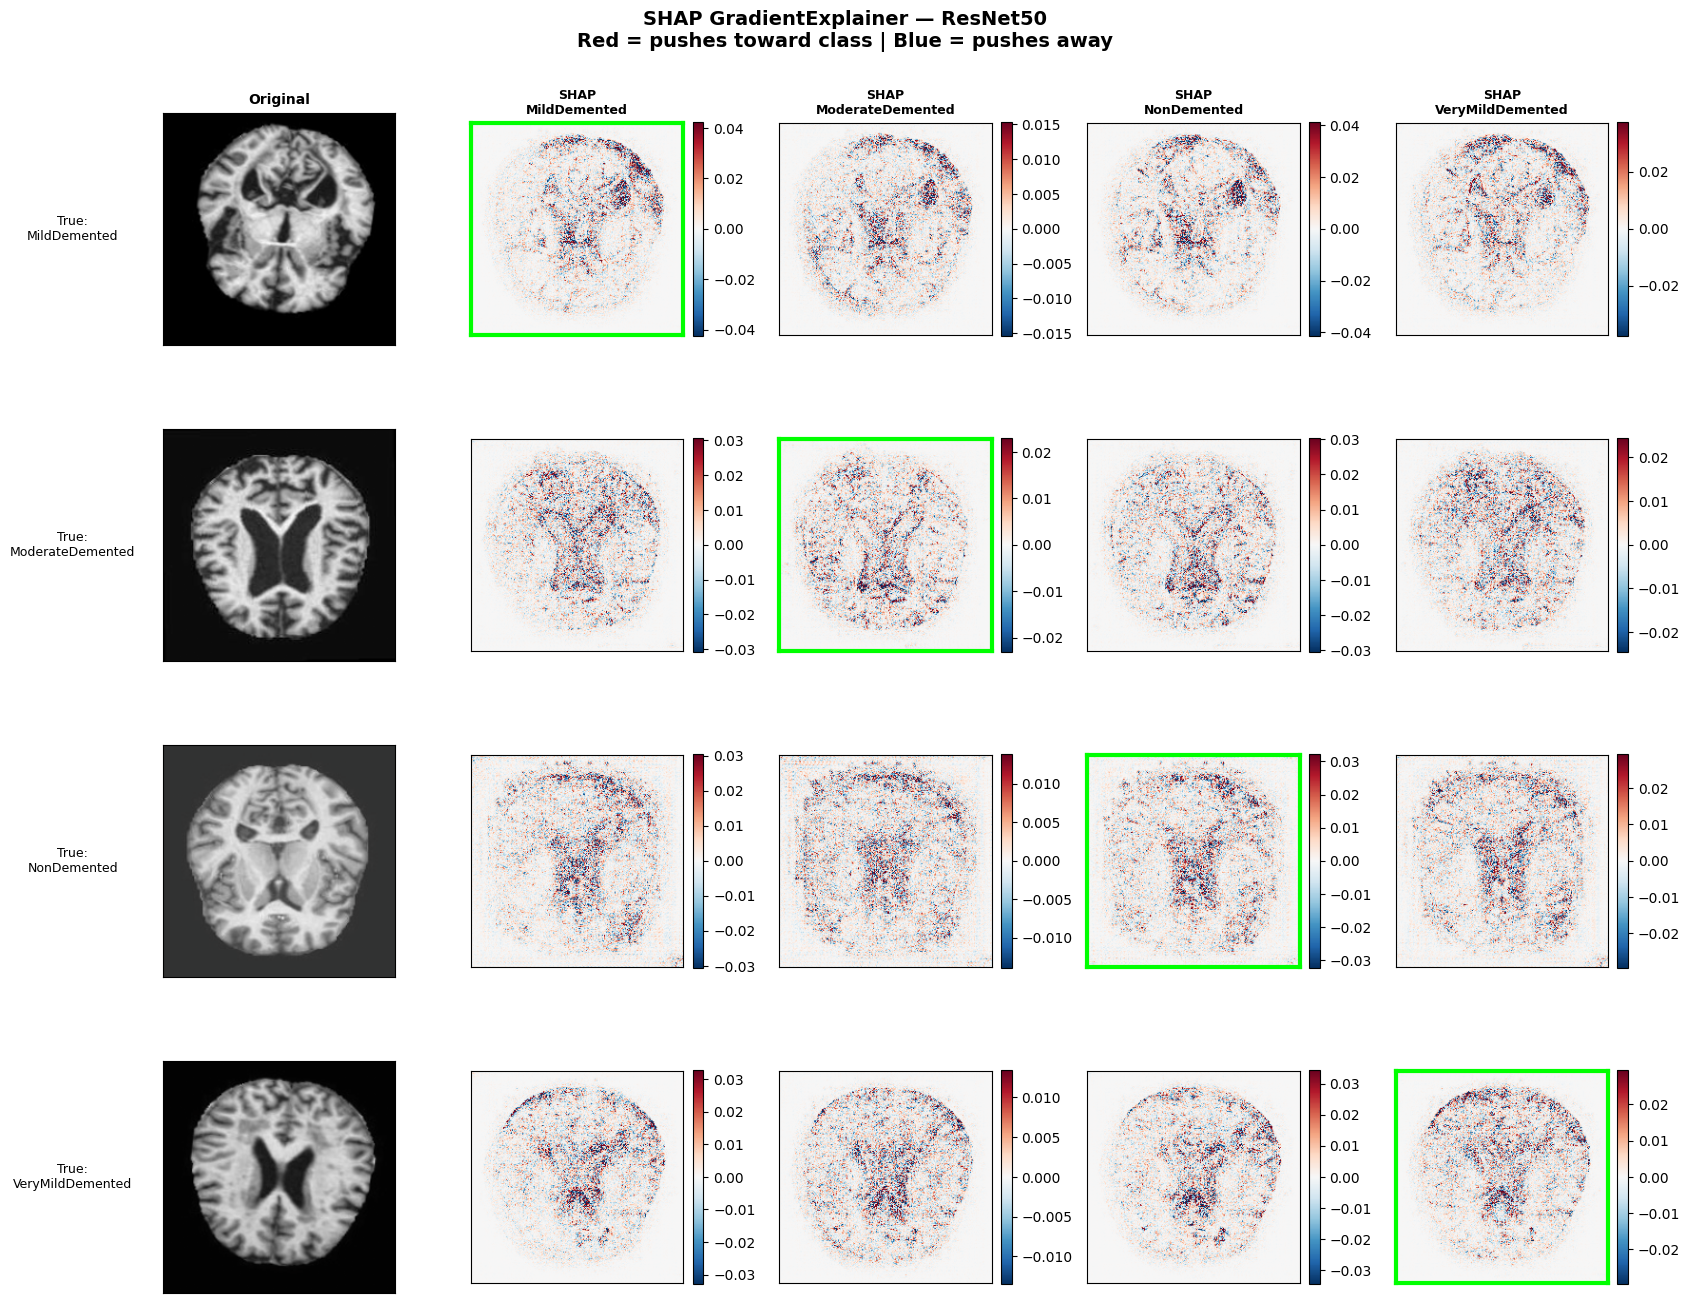

SHAP saved → /kaggle/working/resnet_shap_final_correct.png


In [18]:
# =========================
# FINAL CORRECT SHAP GRID PLOT — ResNet50
# =========================

import numpy as np
import matplotlib.pyplot as plt
import torch

# Convert SHAP output safely
if isinstance(shap_values, list):
    num_shap_classes = len(shap_values)
else:
    # Sometimes shape = (N, C, H, W, classes)
    num_shap_classes = shap_values.shape[-1]

print("Number of SHAP classes:", num_shap_classes)
print("Number of class names:", len(class_names))

fig, axes = plt.subplots(
    n_classes,
    num_shap_classes + 1,
    figsize=(3.4 * (num_shap_classes + 1), 3.4 * n_classes)
)

fig.suptitle(
    "SHAP GradientExplainer — ResNet50\nRed = pushes toward class | Blue = pushes away",
    fontsize=14,
    fontweight="bold"
)

axes[0][0].set_title("Original", fontsize=10, fontweight="bold")

for col in range(num_shap_classes):
    axes[0][col + 1].set_title(f"SHAP\n{class_names[col]}", fontsize=9, fontweight="bold")

for row in range(n_classes):
    img_np = denormalize(xai_images[row])

    with torch.no_grad():
        pred_idx = model(xai_images[row].unsqueeze(0).to(device)).argmax(1).item()

    axes[row][0].imshow(img_np)
    axes[row][0].set_ylabel(
        f"True:\n{class_names[row]}",
        fontsize=9,
        rotation=0,
        labelpad=65,
        va="center"
    )
    axes[row][0].set_xticks([])
    axes[row][0].set_yticks([])

    for col in range(num_shap_classes):
        if isinstance(shap_values, list):
            sv = shap_values[col][row]
        else:
            sv = shap_values[row, :, :, :, col]

        if isinstance(sv, torch.Tensor):
            sv = sv.detach().cpu().numpy()

        # Handle C,H,W or H,W,C
        if sv.ndim == 3 and sv.shape[0] == 3:
            sv_2d = sv.mean(axis=0)
        elif sv.ndim == 3 and sv.shape[-1] == 3:
            sv_2d = sv.mean(axis=-1)
        else:
            sv_2d = sv.squeeze()

        vmax = np.percentile(np.abs(sv_2d), 99)
        if vmax == 0:
            vmax = np.max(np.abs(sv_2d)) + 1e-8

        ax = axes[row][col + 1]
        im = ax.imshow(sv_2d, cmap="RdBu_r", vmin=-vmax, vmax=vmax)

        if col == pred_idx:
            for spine in ax.spines.values():
                spine.set_edgecolor("lime")
                spine.set_linewidth(3)

        ax.set_xticks([])
        ax.set_yticks([])

        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig("/kaggle/working/resnet_shap_final_correct.png", dpi=150, bbox_inches="tight")
plt.show()

print("SHAP saved → /kaggle/working/resnet_shap_final_correct.png")